In [31]:
%pip install requests pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [32]:
import re
import requests
import pandas as pd
from datetime import datetime, timedelta

API_KEY = "oK/SXE39wQjxD5RkfOdan7ofCX4JDogC"
BASE_URL = "https://marsapi.ams.usda.gov/services/v1.2/reports"

In [33]:
end_date = datetime.today()
start_date = end_date - timedelta(days=365)
date_filter = f"{start_date.strftime('%m/%d/%Y')}:{end_date.strftime('%m/%d/%Y')}"

resp = requests.get(
    f"{BASE_URL}/3192",
    params={"q": f"report_begin_date={date_filter}"},
    auth=(API_KEY, "")
)
print("Status:", resp.status_code)
data = resp.json()
records = data.get("results", data) if isinstance(data, dict) else data
print("Records pulled:", len(records))

Status: 200
Records pulled: 251


In [34]:
def parse_narrative(narrative, commodity):
    m = re.search(rf'{commodity}:\s*([\d.]+)\s*\(([+-]?\d+)([A-Za-z])\)', narrative or '')
    if not m:
        return None
    cash = float(m.group(1))
    basis = float(m.group(2)) / 100
    futures = cash - basis
    return cash, futures

corn_rows, soy_rows = [], []
for r in records:
    date = r.get('report_date')
    narrative = r.get('report_narrative', '') or ''
    corn = parse_narrative(narrative, 'Corn')
    soy = parse_narrative(narrative, 'Soybeans')
    if corn:
        corn_rows.append({'date': date, 'cash': corn[0], 'futures': corn[1]})
    if soy:
        soy_rows.append({'date': date, 'cash': soy[0], 'futures': soy[1]})

corn_df = pd.DataFrame(corn_rows)
corn_df['date'] = pd.to_datetime(corn_df['date'])
corn_df = corn_df.sort_values('date').reset_index(drop=True)

soy_df = pd.DataFrame(soy_rows)
soy_df['date'] = pd.to_datetime(soy_df['date'])
soy_df = soy_df.sort_values('date').reset_index(drop=True)

print("Corn rows:", len(corn_df))
print(corn_df.tail())
print("\nSoybean rows:", len(soy_df))
print(soy_df.tail())

Corn rows: 246
          date  cash  futures
241 2026-07-22  4.47     4.62
242 2026-07-23  4.49     4.64
243 2026-07-24  4.49     4.64
244 2026-07-27  4.36     4.51
245 2026-07-28  4.44     4.59

Soybean rows: 251
          date   cash  futures
246 2026-07-22  12.26    12.33
247 2026-07-23  12.30    12.37
248 2026-07-24  12.41    12.48
249 2026-07-27  12.01    12.08
250 2026-07-28  12.05    12.12


In [35]:
import time

def fetch_yahoo_history(ticker, start_date, end_date):
    period1 = int(time.mktime(start_date.timetuple()))
    period2 = int(time.mktime(end_date.timetuple()))
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}"
    params = {"period1": period1, "period2": period2, "interval": "1d"}
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, params=params, headers=headers)
    print(f"{ticker} status:", resp.status_code)
    data = resp.json()
    result = data['chart']['result'][0]
    timestamps = result['timestamp']
    closes = result['indicators']['quote'][0]['close']
    df = pd.DataFrame({'date': pd.to_datetime(timestamps, unit='s'), 'close': closes})
    return df.dropna()

wheat_df = fetch_yahoo_history("ZW=F", start_date, end_date)
print("Wheat futures rows:", len(wheat_df))
print(wheat_df.tail())

ZW=F status: 200
Wheat futures rows: 251
                   date   close
246 2026-07-22 04:00:00  705.75
247 2026-07-23 04:00:00  696.25
248 2026-07-24 04:00:00  678.00
249 2026-07-27 04:00:00  660.00
251 2026-07-29 00:54:58  670.00


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.5 MB 8.2 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 8.6 MB/s eta 0:00:01
   ---------------------- ----------------- 5.2/9.5 MB 9.1 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 7.5 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 7.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 6.8 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------- ------------------------------- 1.6/7.2 MB 10.3 MB/s eta 0:00:01
   ------------- --------------------

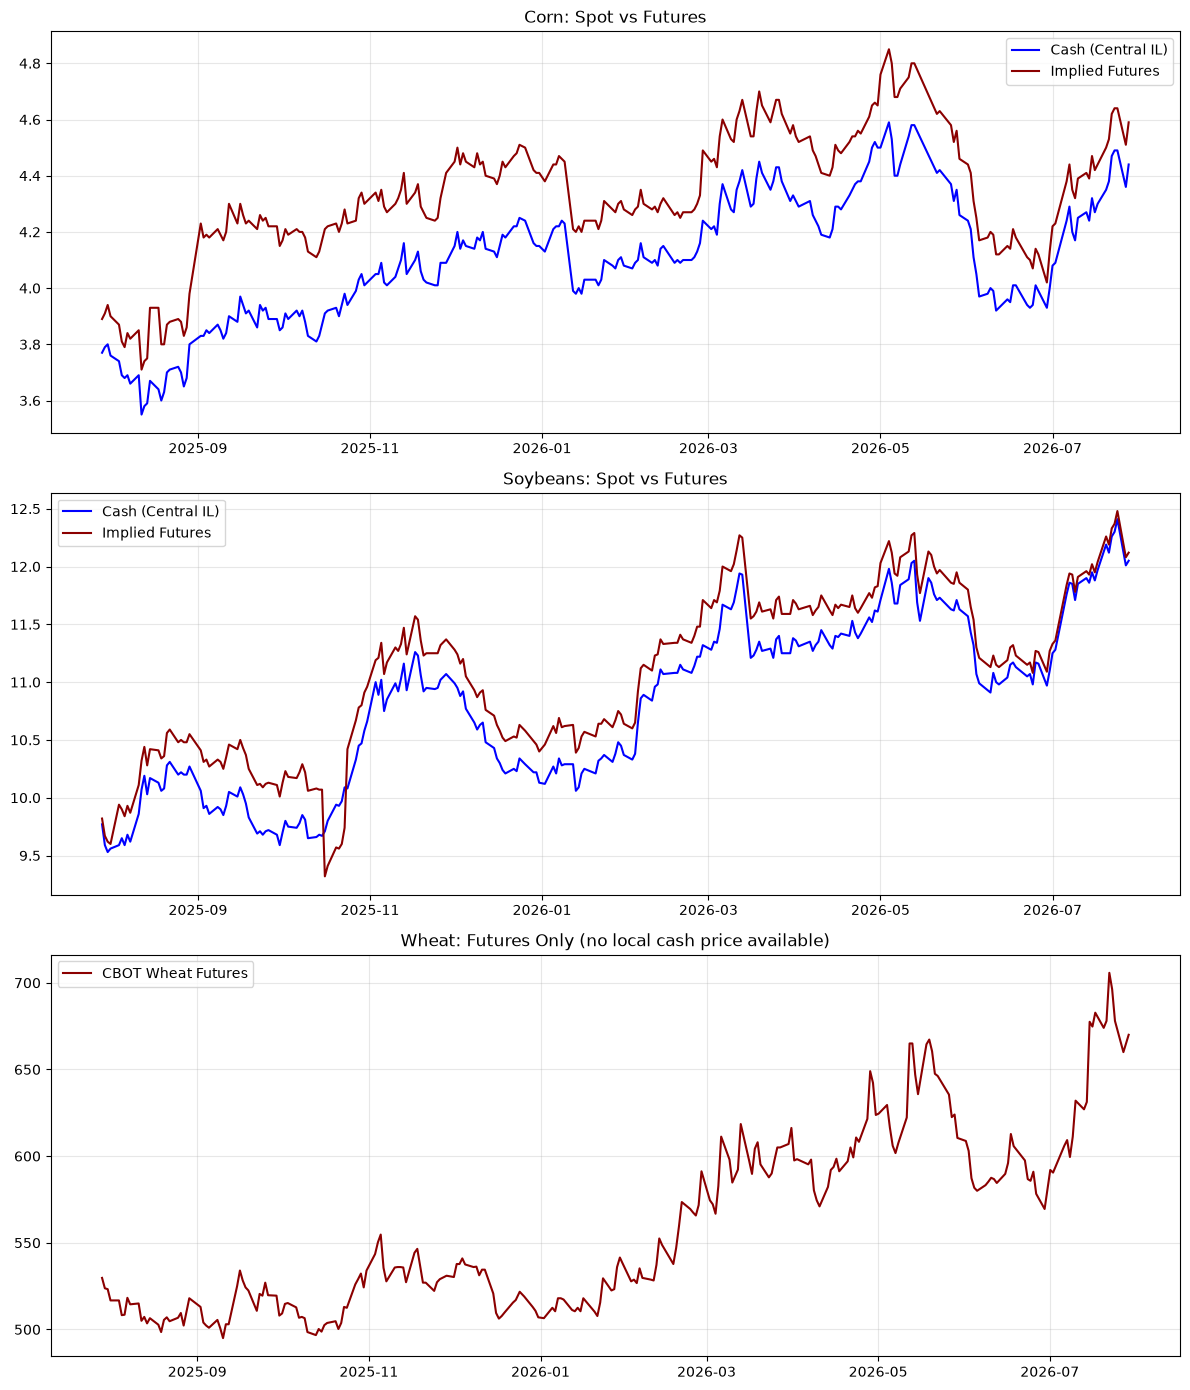

In [37]:

%pip install matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Corn
axes[0].plot(corn_df['date'], corn_df['cash'], label='Cash (Central IL)', color='blue')
axes[0].plot(corn_df['date'], corn_df['futures'], label='Implied Futures', color='darkred')
axes[0].set_title('Corn: Spot vs Futures')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Soybeans
axes[1].plot(soy_df['date'], soy_df['cash'], label='Cash (Central IL)', color='blue')
axes[1].plot(soy_df['date'], soy_df['futures'], label='Implied Futures', color='darkred')
axes[1].set_title('Soybeans: Spot vs Futures')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Wheat (futures only)
axes[2].plot(wheat_df['date'], wheat_df['close'], label='CBOT Wheat Futures', color='darkred')
axes[2].set_title('Wheat: Futures Only (no local cash price available)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

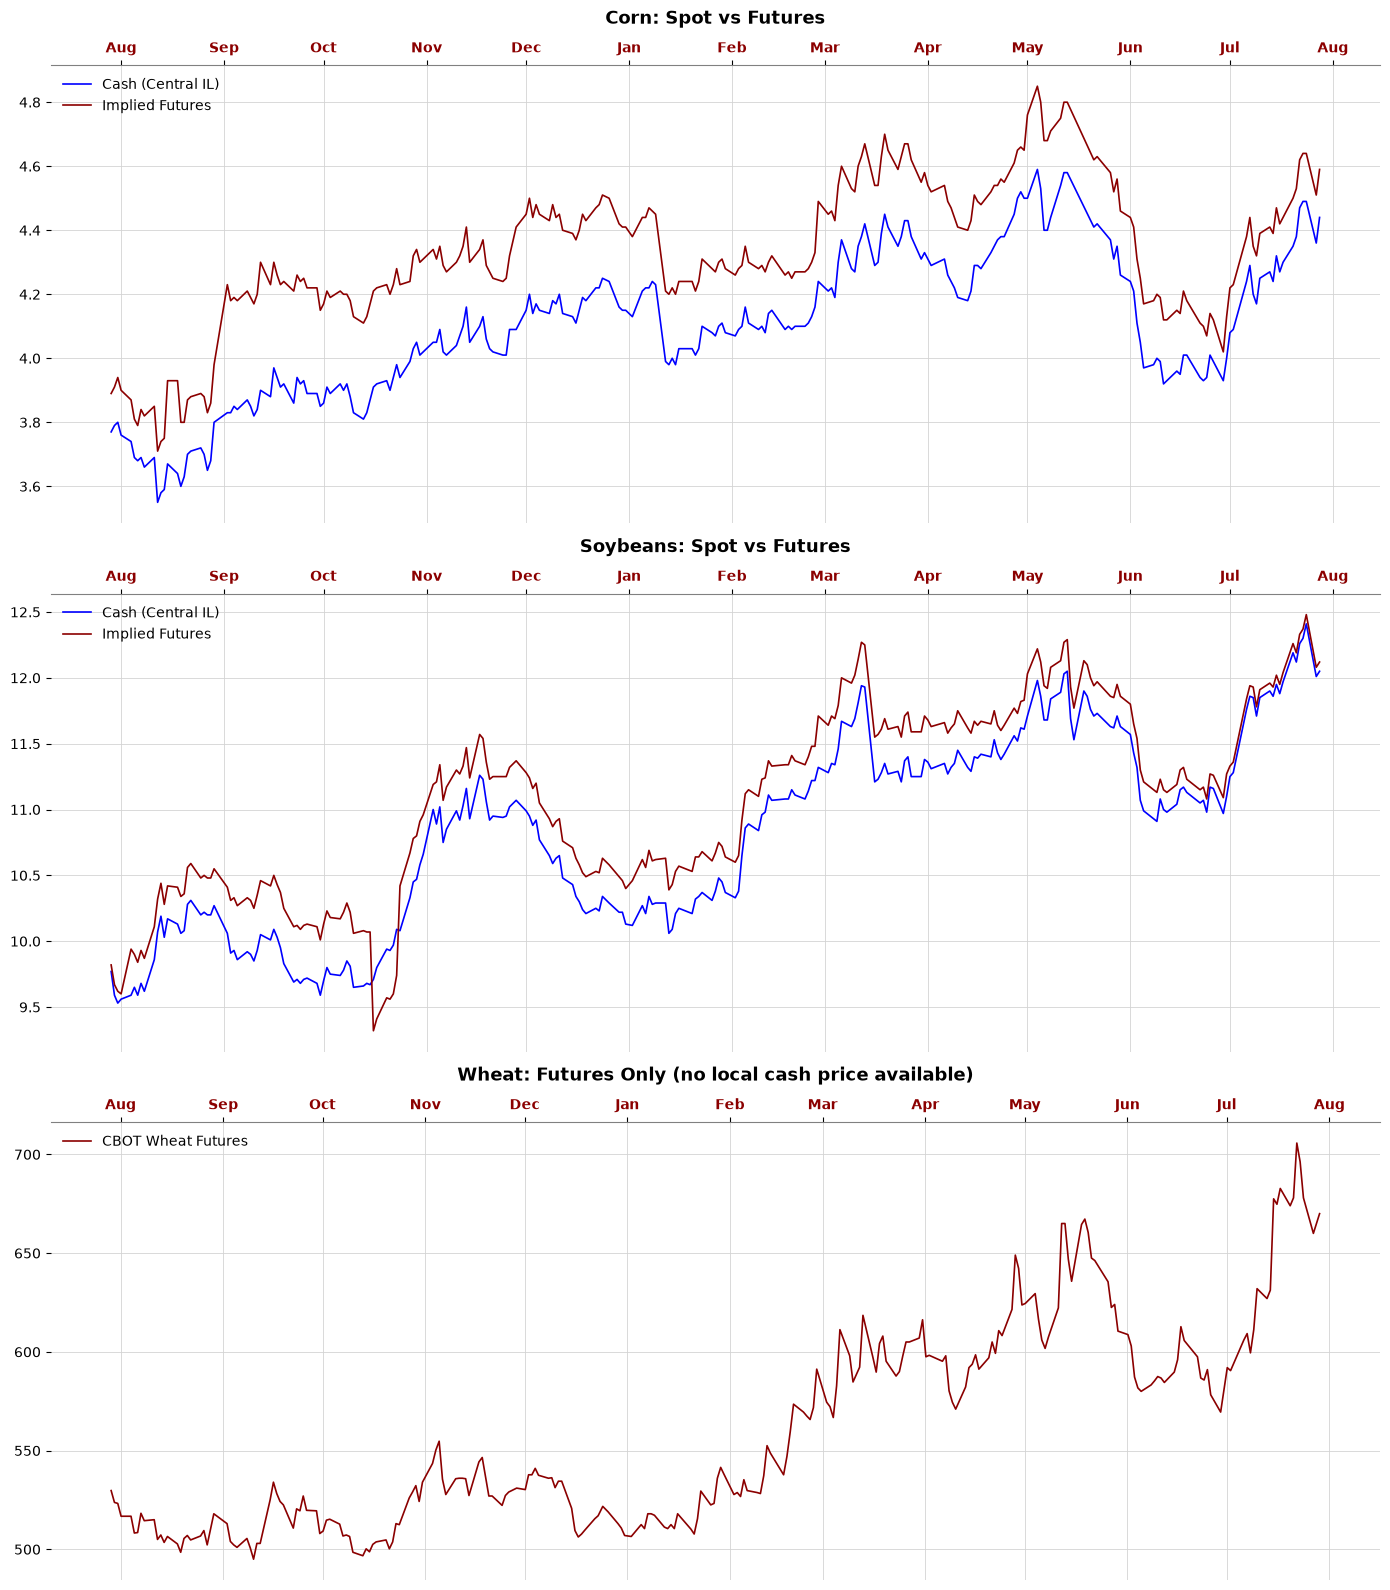

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def style_chart(ax, title):
    ax.set_title(title, fontsize=13, fontweight='bold', pad=30)
    ax.legend(loc='upper left', frameon=False)

    # Month labels across the top
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center', color='darkred', fontweight='bold')

    # Gridlines: light horizontal + light vertical
    ax.grid(True, which='major', axis='both', color='lightgray', linewidth=0.6, linestyle='-')
    ax.set_axisbelow(True)

    # Clean up borders
    for spine in ['left', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.spines['top'].set_color('gray')

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Corn
axes[0].plot(corn_df['date'], corn_df['cash'], label='Cash (Central IL)', color='blue', linewidth=1.2)
axes[0].plot(corn_df['date'], corn_df['futures'], label='Implied Futures', color='darkred', linewidth=1.2)
style_chart(axes[0], 'Corn: Spot vs Futures')

# Soybeans
axes[1].plot(soy_df['date'], soy_df['cash'], label='Cash (Central IL)', color='blue', linewidth=1.2)
axes[1].plot(soy_df['date'], soy_df['futures'], label='Implied Futures', color='darkred', linewidth=1.2)
style_chart(axes[1], 'Soybeans: Spot vs Futures')

# Wheat (futures only)
axes[2].plot(wheat_df['date'], wheat_df['close'], label='CBOT Wheat Futures', color='darkred', linewidth=1.2)
style_chart(axes[2], 'Wheat: Futures Only (no local cash price available)')

plt.tight_layout()
plt.show()

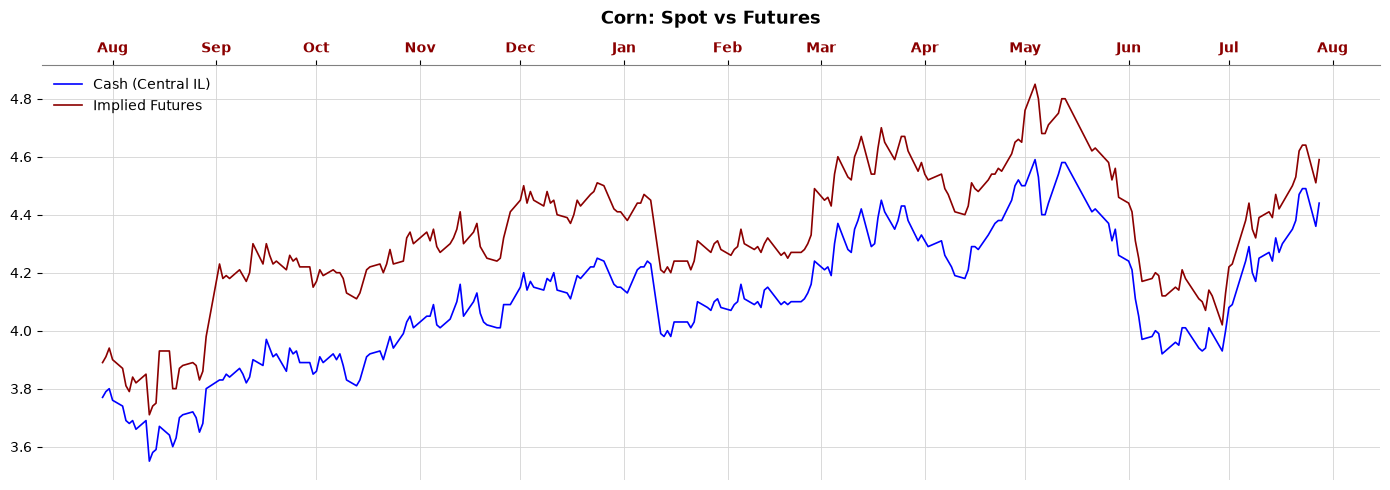

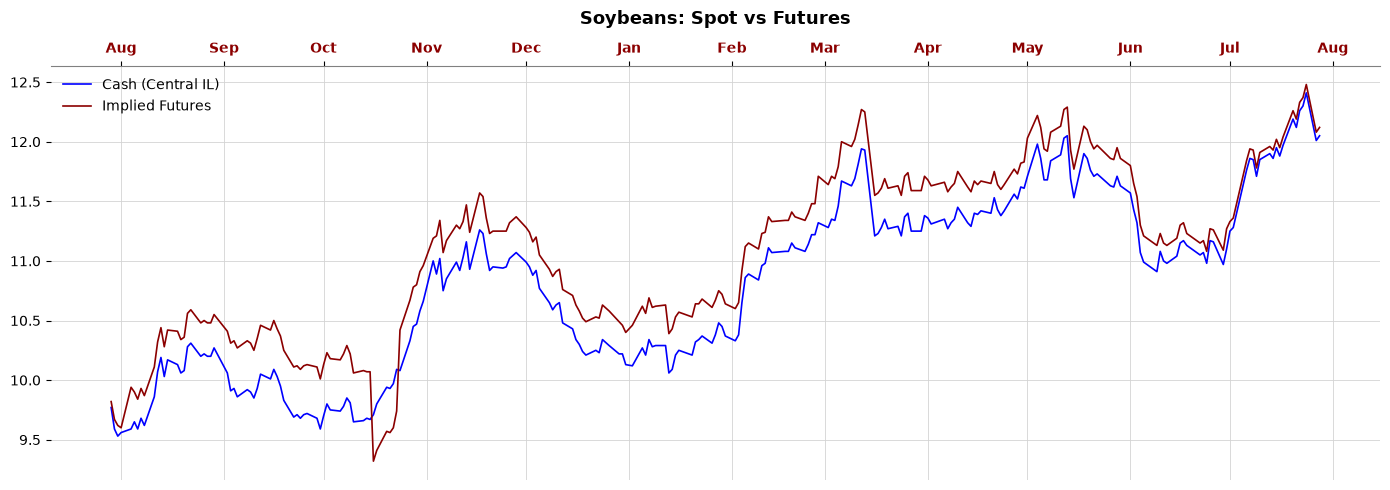

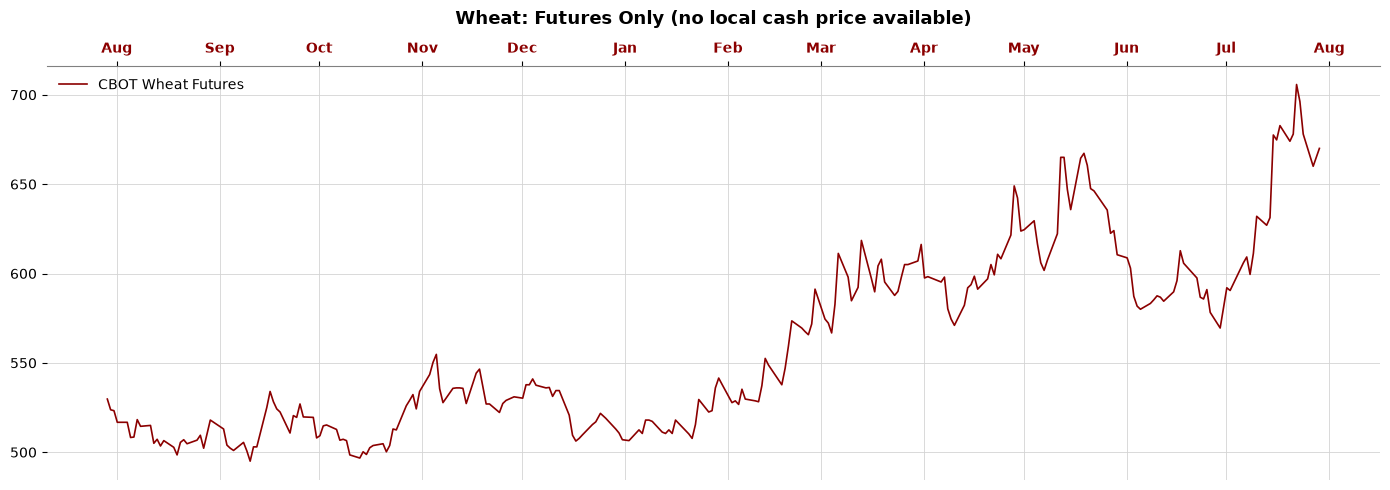

In [40]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def style_chart(ax, title):
    ax.set_title(title, fontsize=13, fontweight='bold', pad=30)
    ax.legend(loc='upper left', frameon=False)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center', color='darkred', fontweight='bold')
    ax.grid(True, which='major', axis='both', color='lightgray', linewidth=0.6, linestyle='-')
    ax.set_axisbelow(True)
    for spine in ['left', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.spines['top'].set_color('gray')

# Corn
fig1, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(corn_df['date'], corn_df['cash'], label='Cash (Central IL)', color='blue', linewidth=1.2)
ax1.plot(corn_df['date'], corn_df['futures'], label='Implied Futures', color='darkred', linewidth=1.2)
style_chart(ax1, 'Corn: Spot vs Futures')
plt.tight_layout()
plt.show()

# Soybeans
fig2, ax2 = plt.subplots(figsize=(14, 5))
ax2.plot(soy_df['date'], soy_df['cash'], label='Cash (Central IL)', color='blue', linewidth=1.2)
ax2.plot(soy_df['date'], soy_df['futures'], label='Implied Futures', color='darkred', linewidth=1.2)
style_chart(ax2, 'Soybeans: Spot vs Futures')
plt.tight_layout()
plt.show()

# Wheat
fig3, ax3 = plt.subplots(figsize=(14, 5))
ax3.plot(wheat_df['date'], wheat_df['close'], label='CBOT Wheat Futures', color='darkred', linewidth=1.2)
style_chart(ax3, 'Wheat: Futures Only (no local cash price available)')
plt.tight_layout()
plt.show()

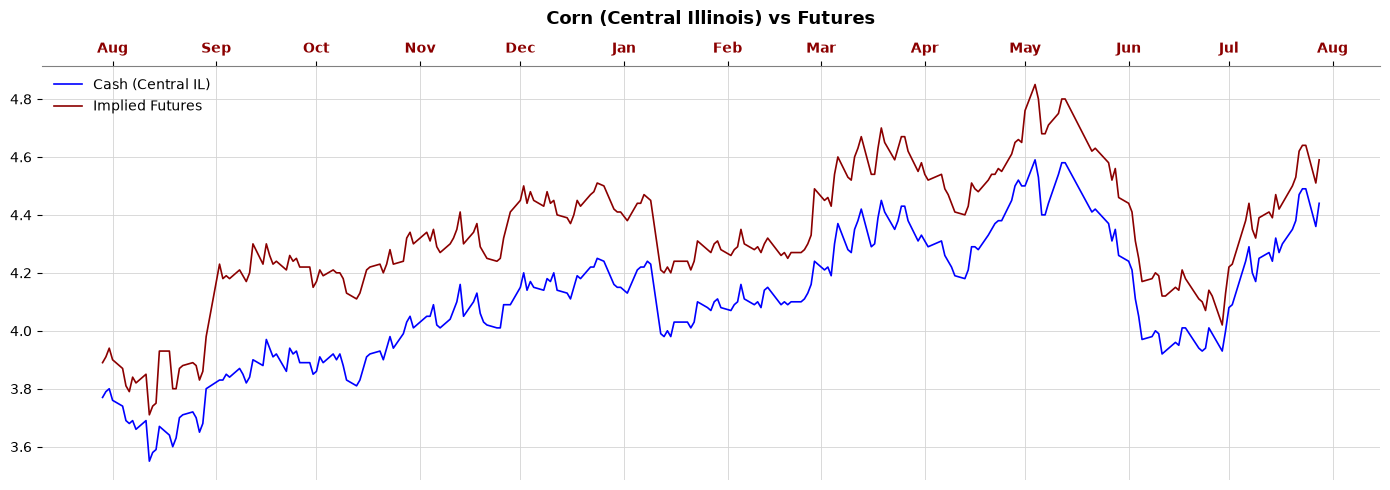

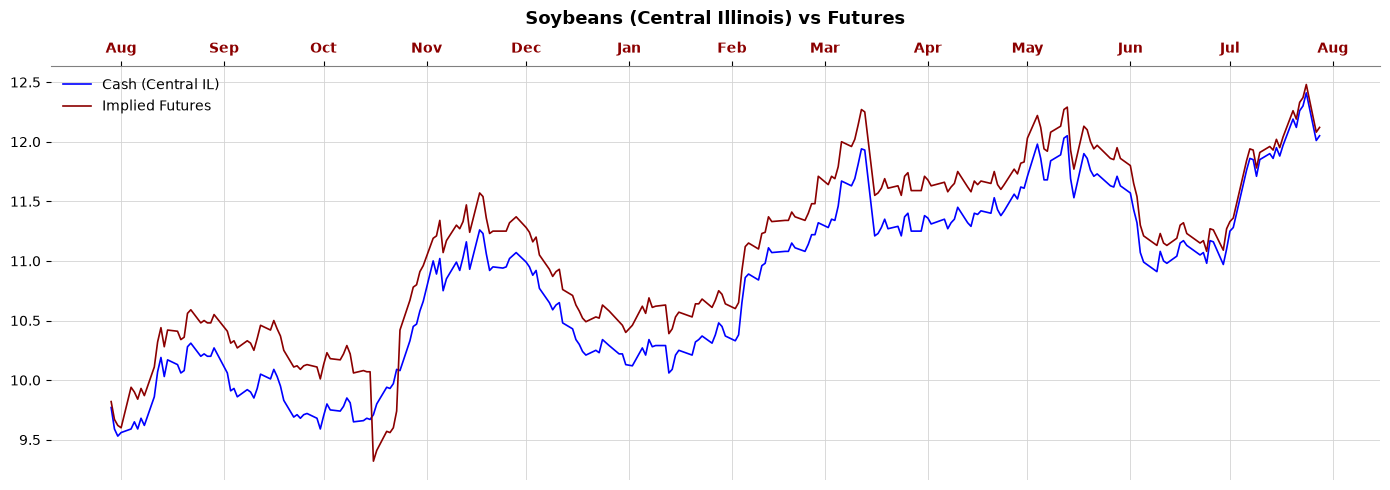

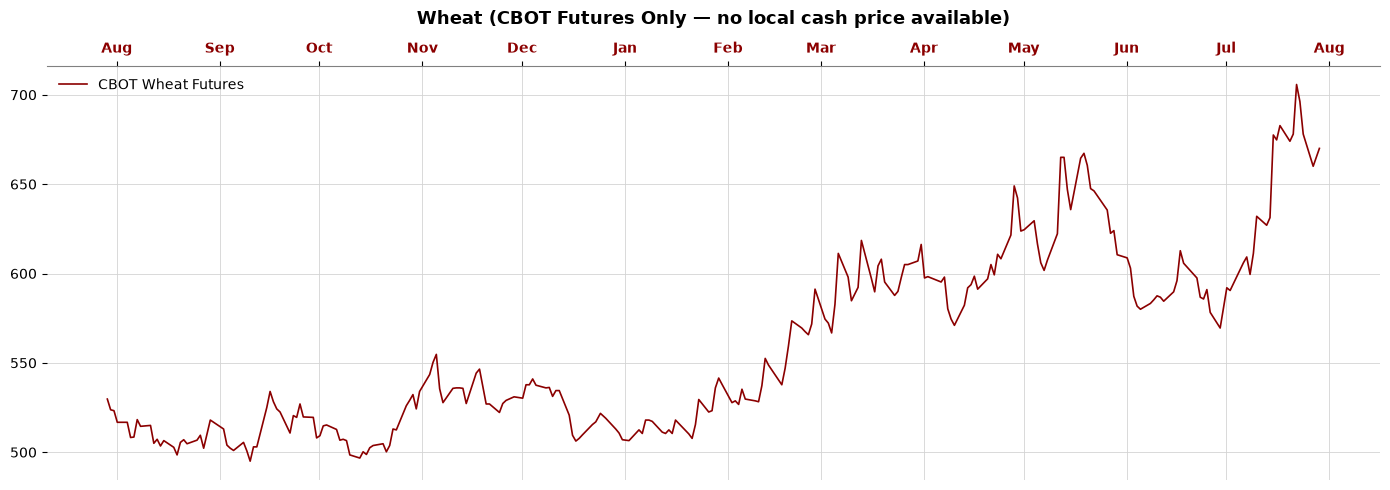

In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def style_chart(ax, title):
    ax.set_title(title, fontsize=13, fontweight='bold', pad=30)
    ax.legend(loc='upper left', frameon=False)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center', color='darkred', fontweight='bold')
    ax.grid(True, which='major', axis='both', color='lightgray', linewidth=0.6, linestyle='-')
    ax.set_axisbelow(True)
    for spine in ['left', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.spines['top'].set_color('gray')

# Corn
fig1, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(corn_df['date'], corn_df['cash'], label='Cash (Central IL)', color='blue', linewidth=1.2)
ax1.plot(corn_df['date'], corn_df['futures'], label='Implied Futures', color='darkred', linewidth=1.2)
style_chart(ax1, 'Corn (Central Illinois) vs Futures')
plt.tight_layout()
plt.show()

# Soybeans
fig2, ax2 = plt.subplots(figsize=(14, 5))
ax2.plot(soy_df['date'], soy_df['cash'], label='Cash (Central IL)', color='blue', linewidth=1.2)
ax2.plot(soy_df['date'], soy_df['futures'], label='Implied Futures', color='darkred', linewidth=1.2)
style_chart(ax2, 'Soybeans (Central Illinois) vs Futures')
plt.tight_layout()
plt.show()

# Wheat
fig3, ax3 = plt.subplots(figsize=(14, 5))
ax3.plot(wheat_df['date'], wheat_df['close'], label='CBOT Wheat Futures', color='darkred', linewidth=1.2)
style_chart(ax3, 'Wheat (CBOT Futures Only \u2014 no local cash price available)')
plt.tight_layout()
plt.show()